## Importing and preparing dataset

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d jangedoo/utkface-new

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
utkface-new.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/utkface-new.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
import os
import numpy as np
import pandas as pd

In [ ]:
folder_path = '/content/utkface_aligned_cropped/UTKFace'

age = []
gender = []
image_path = []

for file in os.listdir(folder_path):
  age.append(int(file.split('_')[0]))
  gender.append(int(file.split('_')[1]))
  image_path.append(file)

In [ ]:
df = pd.DataFrame({'age': age, 'gender': gender, 'image_path': image_path})
df.head()

,age,gender,image_path
0,26,1,26_1_3_20170119193111657.jpg.chip.jpg
1,32,0,32_0_1_20170113142507421.jpg.chip.jpg
2,32,1,32_1_1_20170114024610489.jpg.chip.jpg
3,26,1,26_1_4_20170117174054694.jpg.chip.jpg
4,38,0,38_0_1_201701162330572788.jpg.chip.jpg


In [ ]:
df.shape

(23708, 3)

In [ ]:
train_df = df.sample(frac=1,random_state=0).iloc[:20000]
test_df = df.sample(frac=1,random_state=0).iloc[20000:]

In [ ]:
import tensorflow as tf
import keras
from keras.layers import *
from keras.models import Model
from keras.applications.resnet50 import ResNet50

In [ ]:
train_filepaths = train_df['image_path'].apply(lambda x: os.path.join(folder_path, x)).values
test_filepaths = test_df['image_path'].apply(lambda x: os.path.join(folder_path, x)).values

In [ ]:
train_label_dict = {
    'age': train_df['age'].values,
    'gender': train_df['gender'].values
}

test_label_dict = {
    'age': test_df['age'].values,
    'gender': test_df['gender'].values
}

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_filepaths,train_label_dict))
test_dataset = tf.data.Dataset.from_tensor_slices((test_filepaths,test_label_dict))

In [ ]:
def parse_image(filename, label):
    image_string = tf.io.read_file(filename)
    image = tf.io.decode_jpeg(image_string, channels=3)
    image = tf.image.resize(image, [200, 200])
    return image, label

In [ ]:
Autotune = tf.data.AUTOTUNE
train_dataset = (train_dataset
           .shuffle(buffer_size=len(df))
           .map(parse_image, num_parallel_calls=Autotune)
           .batch(batch_size=32)
           .prefetch(buffer_size=Autotune))

test_dataset = (
    test_dataset
    .shuffle(buffer_size=len(df))
    .map(parse_image, num_parallel_calls=Autotune)
    .batch(batch_size=32)
    .prefetch(buffer_size=Autotune)
)

In [ ]:
data_augmentation = keras.Sequential([
  keras.layers.Rescaling(1./255),
  keras.layers.RandomFlip("horizontal"),
  keras.layers.RandomRotation(0.2),
  keras.layers.RandomZoom(0.2),
  keras.layers.RandomTranslation(0.1, 0.1),
  keras.layers.RandomContrast(0.2),
]
)

In [ ]:
resnet = ResNet50(include_top=False, input_shape=(200,200,3))

resnet.trainable=False

In [ ]:
inputs = Input(shape=(200, 200, 3))
x = data_augmentation(inputs)
augmented_output = resnet(x)

In [ ]:
pooled = GlobalAveragePooling2D()(augmented_output)
batch_norm = BatchNormalization()(pooled)

# Age Branch (Regression)
age_dense1 = Dense(256, activation="relu")(batch_norm)
age_dropout1 = Dropout(0.3)(age_dense1)
age_dense2 = Dense(128, activation="relu")(age_dropout1)
output1 = Dense(1, activation="linear", name="age")(age_dense2)

# Gender Branch (Binary Classification)
gender_dense1 = Dense(256, activation="relu")(batch_norm)
gender_dropout1 = Dropout(0.3)(gender_dense1)
gender_dense2 = Dense(128, activation="relu")(gender_dropout1)
output2 = Dense(1, activation="sigmoid", name="gender")(gender_dense2)

In [ ]:
model = Model(inputs=inputs, outputs=[output1, output2])

In [ ]:
model.compile(optimizer='adam', loss={'age': 'mae', 'gender': 'binary_crossentropy'}, metrics={'age': 'mae', 'gender': 'accuracy'},loss_weights={'age':1,'gender':99})

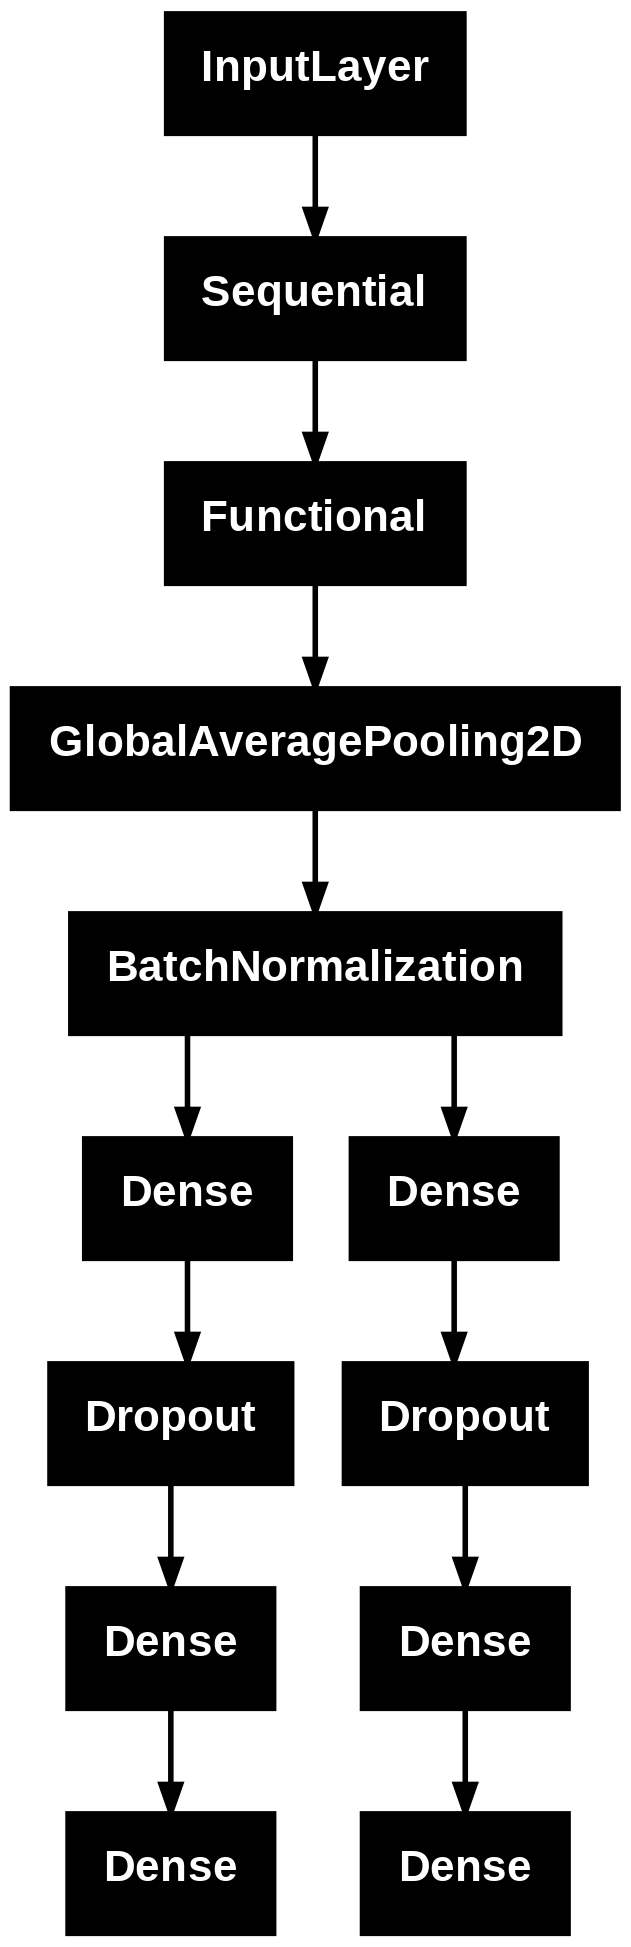

In [ ]:
tf.keras.utils.plot_model(model)

In [ ]:
history = model.fit(train_dataset, epochs=10, validation_data=test_dataset)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 110s 159ms/step - age_loss: 14.9771 - age_mae: 14.9771 - gender_accuracy: 0.6100 - gender_loss: 0.6631 - loss: 80.6220 - val_age_loss: 14.5670 - val_age_mae: 14.5680 - val_gender_accuracy: 0.6667 - val_gender_loss: 0.6144 - val_loss: 75.3932
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 156ms/step - age_loss: 13.7362 - age_mae: 13.7362 - gender_accuracy: 0.6543 - gender_loss: 0.6275 - loss: 75.8546 - val_age_loss: 12.6232 - val_age_mae: 12.6213 - val_gender_accuracy: 0.6917 - val_gender_loss: 0.5843 - val_loss: 70.4585
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 157ms/step - age_loss: 13.2851 - age_mae: 13.2851 - gender_accuracy: 0.6640 - gender_loss: 0.6127 - loss: 73.9393 - val_age_loss: 12.1848 - val_age_mae: 12.1853 - val_gender_accuracy: 0.6969 - val_gender_loss: 0.5802 - val_loss: 69.6213
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 155ms/step - age_loss: 13.0577 - age_mae: 13.0577 - gender_accuracy: 0.6730 - gender_loss: 0.6046 - loss: 72.91

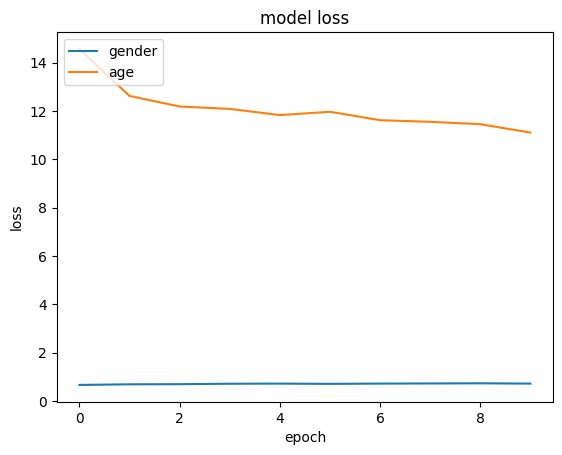

In [ ]:
from matplotlib import pyplot as plt

plt.plot(history.history['val_gender_accuracy'])
plt.plot(history.history['val_age_mae'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['gender', 'age'], loc='upper left')
plt.show()

In [ ]:
model.save('age_gender_predictor.keras')